In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from arch import arch_model

In [37]:
input_file_oil = "C:/Users/deanc/Documents/Datasets/predictive_analytics/DCOILWTICO.csv"
input_file_gas = "C:/Users/deanc/Documents/Datasets/predictive_analytics/GASREGW.csv"

In [38]:
fred_oil = pd.read_csv(input_file_oil)
fred_gas = pd.read_csv(input_file_gas)
fred_oil.head()

,observation_date,DCOILWTICO
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


In [39]:
fred_oil.head()
fred_oil.dtypes

observation_date     object
DCOILWTICO          float64
dtype: object

In [43]:
def clean_fred(df, value_name):
    df = df.copy()
    df = df.rename(columns={"observation_date": "DATE"})
    if "DATE" not in df.columns:
        df["DATE"] = pd.to_datetime(df["DATE"])
    val_col = [c for c in df.columns if c != "DATE"][0]
    df[val_col] = pd.to_numeric(df[val_col].replace(".", np.nan), errors="coerce")
    df = df.rename(columns={val_col: value_name}).sort_values("DATE")
    return df
    
oil = clean_fred(fred_oil, "OIL")
gas = clean_fred(fred_gas, "GAS")
gas.head()

,DATE,GAS
0,1990-08-20,1.191
1,1990-08-27,1.245
2,1990-09-03,1.242
3,1990-09-10,1.252
4,1990-09-17,1.266


In [46]:
df = pd.merge(oil, gas, on="DATE", how="outer").sort_values("DATE")
df[["OIL", "GAS"]] = df[["OIL", "GAS"]].ffill()
df = df.dropna(subset=["OIL", "GAS"]).reset_index(drop=True)

df.head(), df.isna().sum()

(         DATE    OIL    GAS
 0  1990-08-20  28.63  1.191
 1  1990-08-21  28.46  1.191
 2  1990-08-22  30.52  1.191
 3  1990-08-23  31.67  1.191
 4  1990-08-24  31.10  1.191,
 DATE    0
 OIL     0
 GAS     0
 dtype: int64)

In [47]:
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

df = df.dropna(subset=["DATE"]).sort_values("DATE")

df["OIL"] = pd.to_numeric(df["OIL"], errors="coerce")
df["GAS"] = pd.to_numeric(df["GAS"], errors="coerce")
df = df.dropna(subset=["OIL","GAS"])

dfw = (
    df.set_index("DATE")[["OIL","GAS"]]
      .resample("W")
      .mean()
      .dropna()
      .reset_index()
)

dfw.head(), dfw.shape

(        DATE     OIL    GAS
 0 1990-08-26  30.076  1.191
 1 1990-09-02  27.130  1.245
 2 1990-09-09  29.670  1.242
 3 1990-09-16  30.992  1.252
 4 1990-09-23  34.208  1.266,
 (1851, 3))

In [49]:
from statsmodels.tsa.stattools import adfuller
dfw["GAS"] = dfw["GAS"] * 100

def adf_print(x, name):
    x = x.dropna()
    stat, pval, *_ = adfuller(x, autolag="AIC")
    print(f"{name}: ADF stat={stat:.4f}, p-value={pval:.6f}")

adf_print(dfw["OIL"], "OIL (levels)")
adf_print(dfw["GAS"], "GAS (levels)")

OIL (levels): ADF stat=-2.4326, p-value=0.132742
GAS (levels): ADF stat=-1.6935, p-value=0.434481


In [50]:
dfw["log_oil"] = np.log(dfw["OIL"])
dfw["log_gas"] = np.log(dfw["GAS"])

dfw["dlog_oil"] = dfw["log_oil"].diff()
dfw["dlog_gas"] = dfw["log_gas"].diff()

var_df = dfw[["DATE", "dlog_oil", "dlog_gas"]].dropna().reset_index(drop=True)

adf_print(var_df["dlog_oil"], "Δlog(OIL)")
adf_print(var_df["dlog_gas"], "Δlog(GAS)")

Δlog(OIL): ADF stat=-16.5664, p-value=0.000000
Δlog(GAS): ADF stat=-10.6005, p-value=0.000000


In [51]:
model = VAR(var_df[["dlog_oil", "dlog_gas"]])
sel = model.select_order(maxlags=12)
print(sel.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -13.22      -13.22   1.808e-06      -13.22
1       -13.76      -13.74   1.057e-06      -13.75
2       -13.83     -13.80*   9.896e-07      -13.81
3       -13.84      -13.80   9.783e-07     -13.82*
4       -13.84      -13.79   9.749e-07      -13.82
5      -13.84*      -13.78  9.735e-07*      -13.82
6       -13.84      -13.76   9.737e-07      -13.81
7       -13.84      -13.75   9.744e-07      -13.81
8       -13.84      -13.74   9.760e-07      -13.80
9       -13.84      -13.73   9.746e-07      -13.80
10      -13.84      -13.71   9.768e-07      -13.79
11      -13.84      -13.70   9.759e-07      -13.79
12      -13.84      -13.69   9.785e-07      -13.78
--------------------------------------------------


In [52]:
p = sel.aic
var_fit = model.fit(p)

print("Selected lag:", p)
print(var_fit.summary())

Selected lag: 5
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 28, Feb, 2026
Time:                     20:55:32
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -13.7764
Nobs:                     1845.00    HQIC:                  -13.8179
Log likelihood:           7555.55    FPE:                9.73658e-07
AIC:                     -13.8422    Det(Omega_mle):     9.62151e-07
--------------------------------------------------------------------
Results for equation dlog_oil
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000167         0.001598            0.105           0.917
L1.dlog_oil        -0.188084         0.023625           -7.961           0.000
L1.dlog_gas         0.628721         0.111849    

In [53]:
print("OIL → GAS?")
print(var_fit.test_causality("dlog_gas", ["dlog_oil"], kind="f").summary())

print("\nGAS → OIL?")
print(var_fit.test_causality("dlog_oil", ["dlog_gas"], kind="f").summary())

OIL → GAS?
Granger causality F-test. H_0: dlog_oil does not Granger-cause dlog_gas. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         60.39          2.217   0.000 (5, np.int64(3668))
---------------------------------------------------------

GAS → OIL?
Granger causality F-test. H_0: dlog_gas does not Granger-cause dlog_oil. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         8.915          2.217   0.000 (5, np.int64(3668))
---------------------------------------------------------


In [54]:
steps = 12
fc = var_fit.forecast(
    var_df[["dlog_oil","dlog_gas"]].values[-p:], 
    steps=steps
)

fc_df = pd.DataFrame(fc, columns=["dlog_oil_fc","dlog_gas_fc"])
fc_df

,dlog_oil_fc,dlog_gas_fc
0,-0.000096,0.004564
1,0.004400,0.003563
2,0.001406,0.002797
3,0.001265,0.000738
4,-0.001915,0.000988
5,-0.000007,0.000634
6,0.000739,0.000332
7,0.000133,0.000318
8,0.000070,0.000342
9,0.000100,0.000343


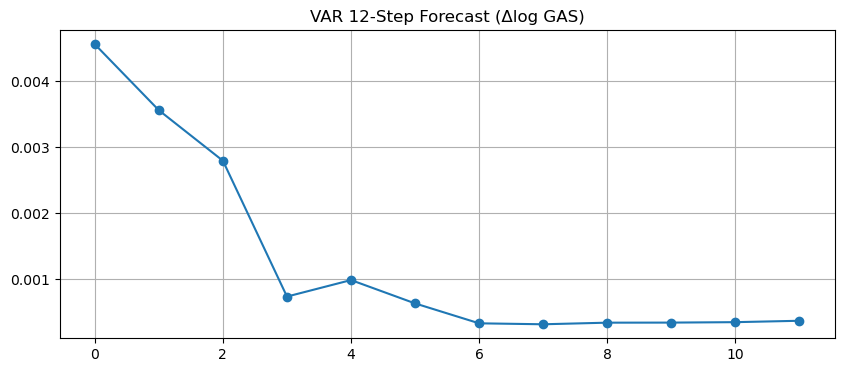

In [55]:
#Figure1
plt.figure(figsize=(10,4))
plt.plot(fc_df["dlog_gas_fc"], marker="o")
plt.title("VAR 12-Step Forecast (Δlog GAS)")
plt.grid(True)
plt.show()

<Figure size 1000x400 with 0 Axes>

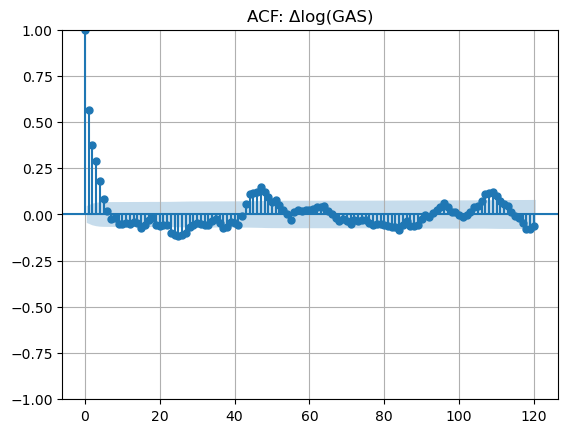

<Figure size 1000x400 with 0 Axes>

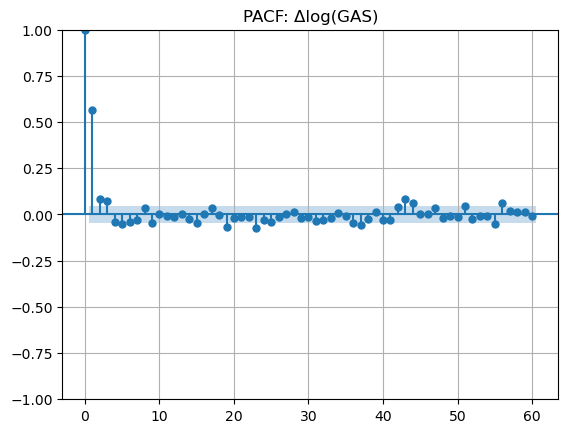

In [56]:
#Figure2
y = var_df["dlog_gas"]

plt.figure(figsize=(10,4))
plot_acf(y.dropna(), lags=120)
plt.title("ACF: Δlog(GAS)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(y.dropna(), lags=60, method="ywm")
plt.title("PACF: Δlog(GAS)")
plt.grid(True)
plt.show()

In [57]:
y = var_df["dlog_gas"]
X = var_df[["dlog_oil"]]

sarimax = SARIMAX(
    y, exog=X,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           dlog_gas   No. Observations:                 1850
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood                4941.020
Date:                            Sat, 28 Feb 2026   AIC                          -9870.039
Time:                                    21:30:28   BIC                          -9837.079
Sample:                                         0   HQIC                         -9857.871
                                           - 1850                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dlog_oil      -0.0172      0.002     -7.996      0.000      -0.021      -0.013
ar.L1          0.6725      0.020   

In [58]:
sarima = SARIMAX(
    y,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("SARIMA  AIC:", sarima.aic, "BIC:", sarima.bic)
print("SARIMAX AIC:", sarimax.aic, "BIC:", sarimax.bic)

SARIMA  AIC: -9856.62830634789 BIC: -9829.161720103579
SARIMAX AIC: -9870.039250351676 BIC: -9837.079346858503


In [59]:
sarima = SARIMAX(
    y,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("SARIMA  AIC:", sarima.aic, "BIC:", sarima.bic)
print("SARIMAX AIC:", sarimax.aic, "BIC:", sarimax.bic)

SARIMA  AIC: -9856.62830634789 BIC: -9829.161720103579
SARIMAX AIC: -9870.039250351676 BIC: -9837.079346858503


In [64]:
steps = 12

y_all = var_df["dlog_gas"]
X_all = var_df[["dlog_oil"]]

y_train, y_test = y_all.iloc[:-steps], y_all.iloc[-steps:]
X_train, X_test = X_all.iloc[:-steps], X_all.iloc[-steps:]

sarimax_tr = SARIMAX(
    y_train, exog=X_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_tr = SARIMAX(
    y_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_x = sarimax_tr.get_forecast(steps=steps, exog=X_test).predicted_mean
pred_no = sarima_tr.get_forecast(steps=steps).predicted_mean

mae_x = mean_absolute_error(y_test, pred_x)
rmse_x = np.sqrt(mean_squared_error(y_test, pred_x))

mae_no = mean_absolute_error(y_test, pred_no)
rmse_no = np.sqrt(mean_squared_error(y_test, pred_no))

print("WITH exog (SARIMAX)  MAE:", mae_x, "RMSE:", rmse_x)
print("NO exog (SARIMA)     MAE:", mae_no, "RMSE:", rmse_no)

WITH exog (SARIMAX)  MAE: 0.012059439711926544 RMSE: 0.014077858574066794
NO exog (SARIMA)     MAE: 0.01196746230223505 RMSE: 0.013972164317676858


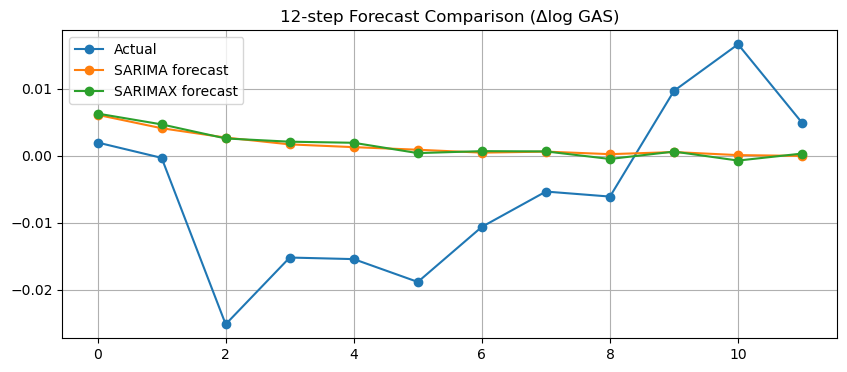

In [65]:
#Figure 3
plt.figure(figsize=(10,4))
plt.plot(y_test.values, marker="o", label="Actual")
plt.plot(pred_no.values, marker="o", label="SARIMA forecast")
plt.plot(pred_x.values, marker="o", label="SARIMAX forecast")
plt.title("12-step Forecast Comparison (Δlog GAS)")
plt.grid(True)
plt.legend()
plt.show()

In [66]:
oil_ret = var_df["dlog_oil"]

lm_test = het_arch(oil_ret.dropna())
print("ARCH LM p-value:", lm_test[1])

ARCH LM p-value: 1.5046178802701637e-136


In [71]:
oil_ret = var_df["dlog_oil"]

arch1 = arch_model(
    oil_ret,
    mean="Zero",
    vol="ARCH",
    p=1
).fit(disp="off")

print(arch1.summary())

C:\Users\deanc\anaconda3\envs\AWS_ML_Book\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.005007. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                        Zero Mean - ARCH Model Results                        
Dep. Variable:               dlog_oil   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                       ARCH   Log-Likelihood:                3197.46
Distribution:                  Normal   AIC:                          -6390.92
Method:            Maximum Likelihood   BIC:                          -6379.87
                                        No. Observations:                 1850
Date:                Sat, Feb 28 2026   Df Residuals:                     1850
Time:                        22:00:35   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.1195e-03  9.782e-05     11.444  2.509e-30 [9.

In [73]:
oil_ret = var_df["dlog_oil"] * 100 #To remove the warning above! 

arch1 = arch_model(
    oil_ret,
    mean="Zero",
    vol="ARCH",
    p=1
).fit(disp="off")

print(arch1.summary())

                        Zero Mean - ARCH Model Results                        
Dep. Variable:               dlog_oil   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                       ARCH   Log-Likelihood:               -5322.11
Distribution:                  Normal   AIC:                           10648.2
Method:            Maximum Likelihood   BIC:                           10659.3
                                        No. Observations:                 1850
Date:                Sat, Feb 28 2026   Df Residuals:                     1850
Time:                        22:03:24   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega         11.1946      0.979     11.439  2.673e-30 [  9.277, 13.11

In [74]:
garch11 = arch_model(
    oil_ret,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
).fit(disp="off")

print(garch11.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:               dlog_oil   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -5244.24
Distribution:                  Normal   AIC:                           10494.5
Method:            Maximum Likelihood   BIC:                           10511.0
                                        No. Observations:                 1850
Date:                Sat, Feb 28 2026   Df Residuals:                     1850
Time:                        22:09:39   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.9419      0.434      2.172  2.988e-02 [9.183e-0

In [75]:
garch11 = arch_model(
    oil_ret,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
).fit(disp="off")

print(garch11.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:               dlog_oil   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -5244.24
Distribution:                  Normal   AIC:                           10494.5
Method:            Maximum Likelihood   BIC:                           10511.0
                                        No. Observations:                 1850
Date:                Sat, Feb 28 2026   Df Residuals:                     1850
Time:                        22:09:49   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.9419      0.434      2.172  2.988e-02 [9.183e-0